## WORKSHOP - 5: License Plate Detection using OpenCV and Haar Cascade Classifier 

### NAME : Sabarish A
### REG. NO : 212225230232
### DATE : 07/09/26

Haar Cascade file not found.
Haar Cascade downloaded successfully!
Haar Cascade loaded successfully!
Image loaded successfully!
Number of plates detected: 1
License plate cropped and saved as plate_crop.png


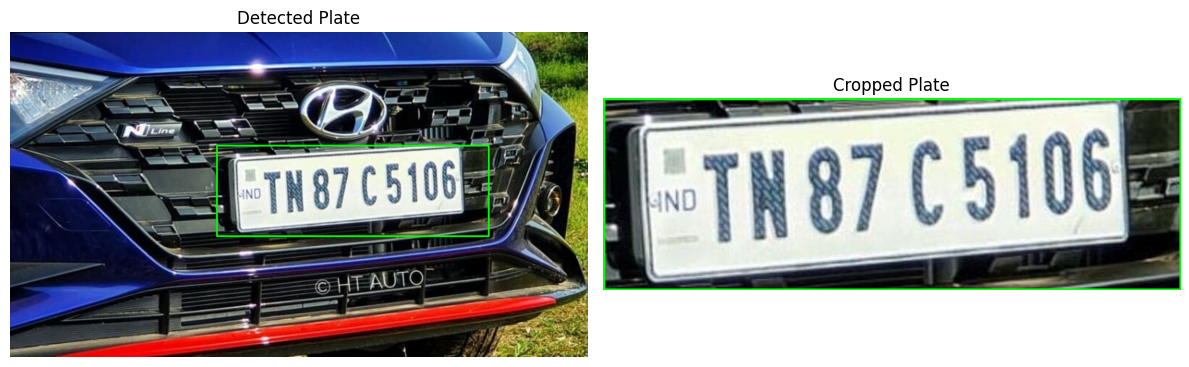

In [5]:
import cv2
import matplotlib.pyplot as plt
import os
import urllib.request

# ============================================================
# WORKSHOP - 5
# License Plate Detection using OpenCV and Haar Cascade
# ============================================================

# ------------------------------------------------------------
# 1. Download Haar Cascade XML if it is not already available
# ------------------------------------------------------------

cascade_file = "haarcascade_russian_plate_number.xml"

cascade_url = (
    "https://raw.githubusercontent.com/opencv/opencv/"
    "4.x/data/haarcascades/haarcascade_russian_plate_number.xml"
)

if not os.path.exists(cascade_file):
    print("Haar Cascade file not found.")
    print("Downloading Haar Cascade XML...")

    try:
        urllib.request.urlretrieve(cascade_url, cascade_file)
        print("Haar Cascade downloaded successfully!")
    except Exception as e:
        raise RuntimeError(
            "Could not download the Haar Cascade XML file.\n"
            "Please check your internet connection."
        ) from e


# ------------------------------------------------------------
# 2. Load Haar Cascade
# ------------------------------------------------------------

plate_cascade = cv2.CascadeClassifier(cascade_file)

if plate_cascade.empty():
    raise RuntimeError(
        "Haar Cascade could not be loaded.\n"
        "Check the XML file."
    )

print("Haar Cascade loaded successfully!")


# ------------------------------------------------------------
# 3. Load Input Image
# ------------------------------------------------------------

image_file = "carplate.jpeg"

img = cv2.imread(image_file)

if img is None:
    raise FileNotFoundError(
        f"Image '{image_file}' was not found.\n"
        "Make sure carplate.jpeg is in the same folder as this notebook."
    )

print("Image loaded successfully!")


# ------------------------------------------------------------
# 4. Preprocessing
# ------------------------------------------------------------

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

blurred = cv2.GaussianBlur(
    gray,
    (5, 5),
    0
)


# ------------------------------------------------------------
# 5. License Plate Detection
# ------------------------------------------------------------

plates = plate_cascade.detectMultiScale(
    blurred,
    scaleFactor=1.1,
    minNeighbors=4,
    minSize=(30, 10)
)

print("Number of plates detected:", len(plates))


# ------------------------------------------------------------
# 6. Convert Image for Matplotlib
# ------------------------------------------------------------

img_rgb = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

cropped_plate = None


# ------------------------------------------------------------
# 7. Draw Bounding Box and Crop Plate
# ------------------------------------------------------------

for (x, y, w, h) in plates:

    # Draw green rectangle
    cv2.rectangle(
        img_rgb,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        3
    )

    # Crop detected plate
    cropped_plate = img_rgb[
        y:y + h,
        x:x + w
    ]

    # Save cropped plate
    cv2.imwrite(
        "plate_crop.png",
        cv2.cvtColor(
            cropped_plate,
            cv2.COLOR_RGB2BGR
        )
    )

    print("License plate cropped and saved as plate_crop.png")


# ------------------------------------------------------------
# 8. Display Output
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

# Original image with detected plate
plt.subplot(1, 2, 1)

if len(plates) > 0:
    plt.title("Detected Plate")
else:
    plt.title("No Plate Detected")

plt.imshow(img_rgb)
plt.axis("off")


# Cropped plate
plt.subplot(1, 2, 2)

if cropped_plate is not None:
    plt.title("Cropped Plate")
    plt.imshow(cropped_plate)
else:
    plt.title("Cropped Plate - Not Found")
    plt.text(
        0.5,
        0.5,
        "No license plate detected",
        ha="center",
        va="center",
        fontsize=12
    )

plt.axis("off")

plt.tight_layout()
plt.show()